# 张量网络（torch）

In [5]:
import quante as qt
import quante.torch_utils as qtc
import torch as tc

建立一个 mpo

In [4]:
L = 12
ham = qt.generate.operas.heisenberg_operator(L)
ℋ = ham.to_mpo(L, pauli=False, backend='torch', device='cpu')
ℋ

MPO;  torch.float64;  norm: 9.191e+01;  maxbonddim: 5;  device: cpu;
physdim:    2|    2|    2|    2|    2|    2|    2|    2|    2|    2|    2|    2| 
         ----◻-----◻-----◻-----◻-----◻-----◻-----◻-----◻-----◻-----◻-----◻-----◻----
physdim:    2|    2|    2|    2|    2|    2|    2|    2|    2|    2|    2|    2| 
bonddim:  1     4     5     5     5     5     5     5     5     5     5     5     1
site:        0     1     2     3     4     5     6     7     8     9     10    11 

建立随机 mps

In [6]:
𝜓 = qtc.MPS.random(L, linkdims=4, dtype=tc.float64, device='cpu')
𝜓.show()

MPS;  torch.float64;  norm: 4.788e+04;  maxbonddim: 4;  device: cpu;
physdim:    2|    2|    2|    2|    2|    2|    2|    2|    2|    2|    2|    2| 
         ----◻-----◻-----◻-----◻-----◻-----◻-----◻-----◻-----◻-----◻-----◻-----◻----
bonddim:  1     4     4     4     4     4     4     4     4     4     4     4     1
site:        0     1     2     3     4     5     6     7     8     9     10    11 


正则化

In [7]:
𝜓.orthogonalize_(0)
𝜓.normalize_()
𝜓

MPS;  torch.float64;  norm: 1.000e+00;  maxbonddim: 4;  device: cpu;
physdim:    2|    2|    2|    2|    2|    2|    2|    2|    2|    2|    2|    2| 
         ----◻-----◁-----◁-----◁-----◁-----◁-----◁-----◁-----◁-----◁-----◁-----◁----
bonddim:  1     4     4     4     4     4     4     4     4     4     4     2     1
site:        0     1     2     3     4     5     6     7     8     9     10    11 

完成收缩成矩阵/张量

In [8]:
# convert to vector
vec = 𝜓.to_matrix()
mat = ℋ.to_matrix()
vec.shape, mat.shape

(torch.Size([4096]), torch.Size([4096, 4096]))

## tebd

In [9]:
𝜓t = 𝜓.copy()

gates = ham.trotter_gates(L, tau=0.1, pauli=False)

for pos, gate in zip(*gates):
    𝜓t.apply_gate_(pos, gate)

𝜓t.show()

MPS;  torch.complex128;  norm: 1.000e+00;  maxbonddim: 32;  device: cpu;
physdim:    2|    2|    2|    2|    2|    2|    2|    2|    2|    2|    2|    2| 
         ----▷-----▷-----▷-----▷-----▷-----▷-----▷-----▷-----▷-----▷-----▷-----◻----
bonddim:  1     2     4     8     16    32    16    32    16    8     4     2     1
site:        0     1     2     3     4     5     6     7     8     9     10    11 


## dmrg

In [10]:
# DMRG 求基态
𝜓0 = 𝜓.copy()
ℋ.dmrg(𝜓0, nsweep=5, chi_max=[100], cutoff=[1e-10])

After sweep 0: energy=-5.142090220377615 maxchi=16 maxtruncerr=0.00e+00 time=0.062
After sweep 1: energy=-5.142090632840522 maxchi=64 maxtruncerr=0.00e+00 time=0.050
After sweep 2: energy=-5.142090632840531 maxchi=64 maxtruncerr=0.00e+00 time=0.043
After sweep 3: energy=-5.142090632840529 maxchi=64 maxtruncerr=0.00e+00 time=0.045
After sweep 4: energy=-5.142090632840528 maxchi=64 maxtruncerr=0.00e+00 time=0.047


(tensor(-5.1421, dtype=torch.float64),
 MPS;  torch.float64;  norm: 1.000e+00;  maxbonddim: 64;  device: cpu;
 physdim:    2|    2|    2|    2|    2|    2|    2|    2|    2|    2|    2|    2| 
          ----◻-----◁-----◁-----◁-----◁-----◁-----◁-----◁-----◁-----◁-----◁-----◁----
 bonddim:  1     2     4     8     16    32    64    32    16    8     4     2     1
 site:        0     1     2     3     4     5     6     7     8     9     10    11 )

与 ed 对比

In [11]:
tc.linalg.eigvalsh(mat)

tensor([-5.1421, -4.8611, -4.8611,  ...,  2.7500,  2.7500,  2.7500],
       dtype=torch.float64)

准一维系统 dmrg

```
      0   2   4   6
   ---◻---◻---◻---◻---
      |   |   |   |
   ---◻---◻---◻---◻---
      1   3   5   7
```

In [2]:
from quante.torch_utils.tensor_network.tnclass import MPS
import quante.generate.operas as op
import torch

j1, j2, j3 = 1.0, 2.0, 1.0

for L in range(4, 10):
    
    H_Spart = j1 * op.sum(op.xx(2*i,2*i+2) + op.yy(2*i,2*i+2) + op.zz(2*i,2*i+2) for i in range(L-1))
    H_Lpart = op.sum(j2 * (op.xx(2*i+1,2*i+3) + op.yy(2*i+1,2*i+3)) + j1 * op.zz(2*i+1,2*i+3) for i in range(L-1))
    H_SLpart = j3 * op.sum(op.xx(2*i,2*i+1) + op.yy(2*i,2*i+1) + op.zz(2*i,2*i+1) for i in range(L))
    H = H_Spart + H_Lpart + H_SLpart
    
    Hmpo = H.to_mpo(L=2*L, pauli=False)
    psi0 = MPS.random(2*L, 2, dtype=torch.float64)
    nsweep = 10
    chi_max = [2,10,50,200]
    cutoff = [1e-10]
    res = Hmpo.dmrg(psi0, nsweep, chi_max, cutoff, outputlevel=0)[0]
    print(f"L={L}, E={res.item()}")

L=4, E=-5.149175306097187
L=5, E=-6.549539316733607
L=6, E=-7.967781415010534
L=7, E=-9.3790118670207
L=8, E=-10.793329596691645
L=9, E=-12.20648086543941


## tdvp

In [12]:
# tdvp 求演化
𝜓0 = 𝜓.copy()
𝜓0.to(device='cpu')
ℋ.to(device='cpu')

ts_𝜓s = ℋ.tdvp(𝜓0, t=-1.0j, time_step=-0.1j, chi_max=[40], trunc_cut=[1e-10], outputlevel=0)

for t, 𝜓t in ts_ψs:
    print(f"t = {t:.1f}: Sz = {𝜓t.measure('z', L//2).real}")



t = 0.1: Sz = -0.01832398672969515
t = 0.2: Sz = -0.015668911087819086
t = 0.3: Sz = -0.011335270803615282
t = 0.4: Sz = -0.005457272076564406
t = 0.5: Sz = 0.001783197470990934
t = 0.6: Sz = 0.010162424272362663
t = 0.7: Sz = 0.01942218356518027
t = 0.8: Sz = 0.029278327958101785
t = 0.9: Sz = 0.03943041034507669
t = 1.0: Sz = 0.049572041718182476


## itebd

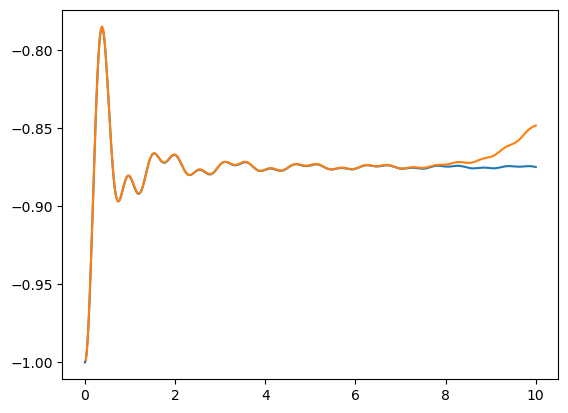

In [14]:
# 无穷长链的演化
from quante.torch_utils.tensor_network.tnclass import MPS
import matplotlib.pyplot as plt
import torch as tc
import numpy as np
import scipy.integrate as spi
import quante as qt

# 解析解，过程见 notes/infinite_xy.md
jx = 1
jy = 0
hz = 2
λ = (jx + jy)/2
γ = (jx - jy)/2
theta = lambda k: np.arctan2(2*γ*np.sin(k),  hz - 2*λ*np.cos(k))
omega = lambda k: 2 * np.sqrt((2*γ*np.sin(k))**2 + (hz - 2*λ*np.cos(k))**2)
ts = np.linspace(0, 10, 500)
sigma_zs = np.zeros_like(ts, dtype=np.float64)
for i, t in enumerate(ts):
    sigma_zs[i] = 1/np.pi * spi.quad(lambda k: np.sin(theta(k))**2 * np.sin(omega(k) * t)**2, -np.pi, np.pi)[0] - 1
plt.plot(ts, sigma_zs)

# 生成无穷长 MPS
tmp1 = tc.zeros(1,2,1, dtype=tc.complex128, device='cpu')
tmp1[0,1,0] = 1.
tmp2 = tc.zeros(1,2,1, dtype=tc.complex128, device='cpu')
tmp2[0,1,0] = 1.

psi = MPS([tmp1, tmp2], [tc.tensor(1., dtype=tc.float64, device='cpu'), tc.tensor(1., dtype=tc.float64, device='cpu')], L=tc.inf)

# 生成两体门
op = qt.generate.operas
g = 2
ham = op.xx(0,1) + 0.5 * g * op.z(0) + 0.5 * g * op.z(1)
basis = qt.generate.basis.spin_basis(2)
mat = ham.to_matrix(basis, pauli=True)
t = 0.02  # 0.05 会有明显误差
expiH = tc.tensor(qt.linalg.expm(mat, -1j*t), dtype=tc.complex128, device='cpu').reshape(2,2,2,2)

# itebd 演化
ts = []
sz = []
bonds = []
cur_t = 0.
for i in range(500):
    psi.apply_gate_(0, expiH, svd_alg='svd', trunc_para=(500,1e-8,None), unitary_gate=True)
    psi.apply_gate_(1, expiH, svd_alg='svd', trunc_para=(500,1e-8,None), unitary_gate=True)
    cur_t += t
    sz.append(psi.measure('Z', 0).real)
    ts.append(cur_t)
    bonds.append(psi.maxbonddim())
plt.plot(ts, sz)

# 运行时间 2m 22.2s